# Bespoke Marketplace — Blended Analysis
**Cornell MSBA Datafest 2026 | Team: Stella Lee, Alexander Warmus, Kevin Flannery**

### Business Goal
Identify patterns in purchasing behavior, artisan performance, and the factors that
drive customer satisfaction — then translate findings into actionable recommendations
to grow Bespoke's platform GMV through positive network externalities.

### Notebook Outline
1. Imports & configuration
2. Load data
3. Clean & preprocess all tables
   - 3a. Transactions
   - 3b. Feedback, items, artisans, buyers, payments
4. Build master `line_items` table
5. Platform overview — scale, ratings, delivery, revenue concentration
6. Artisan feature table + Danger Zone classification + Revenue at Risk
7. Satisfaction × Revenue correlation analysis
   - 7a. 2×2 matrix (median revenue split)
   - 7b. Danger Zone seller profile + logistic regression
   - 7c. Danger Zone: share of sellers, 1-star reviews, and GMV
   - 7d. Complaint theme extraction via BERTopic
8. OLS regression — drivers of buyer satisfaction
9. Delivery timing vs. buyer satisfaction
10. Logistics accountability — carrier vs. artisan attribution
11. Classifier — P(1-star rating) for any given artisan

In [126]:
# Section 1 — Imports and global config
import os, re, warnings
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
    import shap

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

BLUE  = '#378ADD'
RED   = '#E24B4A'
GREEN = '#639922'
AMBER = '#BA7517'
GRAY  = '#888780'

DATA_DIR   = '.'
OUTPUT_DIR = '.'

def csv(name):    return os.path.join(DATA_DIR, name)
def figpath(name): return os.path.join(OUTPUT_DIR, name)


In [127]:
# Section 2 — Load all CSV files
transactions = pd.read_csv(csv('marketplace_transactions.csv'))
tx_details   = pd.read_csv(csv('transaction_details.csv'))
feedback     = pd.read_csv(csv('feedback.csv'))
items        = pd.read_csv(csv('items.csv'))
artisans     = pd.read_csv(csv('artisans.csv'))
buyers       = pd.read_csv(csv('buyers.csv'))
payments     = pd.read_csv(csv('payments.csv'))
cat_trans    = pd.read_csv(csv('item_category_translation.csv'))

try:
    location = pd.read_csv(csv('location_data.csv'))
    location['zip_code_prefix'] = location['zip_code_prefix'].astype(str).str.zfill(5)
    location['city']  = location['city'].str.strip().str.lower()
    location['state'] = location['state'].str.strip().str.upper()
    location = location.groupby('zip_code_prefix').agg(
        latitude=('latitude','mean'), longitude=('longitude','mean'),
        city=('city','first'), state=('state','first'),
    ).reset_index()
    print("  location_data.csv loaded.")
except FileNotFoundError:
    location = None
    print("  location_data.csv not found — skipping geographic enrichment.")

for name, df in [('transactions',transactions), ('tx_details',tx_details),
                 ('feedback',feedback), ('items',items), ('artisans',artisans),
                 ('buyers',buyers), ('payments',payments)]:
    print(f"  {name:20s}: {df.shape[0]:>7,} rows x {df.shape[1]} cols")


  location_data.csv loaded.
  transactions        :  99,441 rows x 8 cols
  tx_details          : 112,650 rows x 7 cols
  feedback            :  99,224 rows x 7 cols
  items               :  32,951 rows x 9 cols
  artisans            :   3,095 rows x 4 cols
  buyers              :  99,441 rows x 5 cols
  payments            : 103,886 rows x 5 cols


In [128]:
# Section 3a — Clean marketplace_transactions
# Per the data dictionary, all date columns use ISO timestamps.
# delivered_date / shipped_date are legitimately null for non-delivered orders.

DATE_COLS = ['purchase_timestamp', 'approved_at', 'shipped_date',
             'delivered_date', 'estimated_delivery_date']
for col in DATE_COLS:
    transactions[col] = pd.to_datetime(transactions[col], errors='coerce')

before = len(transactions)
transactions = transactions.drop_duplicates(subset='transaction_id')
print(f"Removed {before - len(transactions)} duplicate transaction rows")

transactions['transaction_status'] = transactions['transaction_status'].str.strip().str.lower()
print("Status distribution:")
print(transactions['transaction_status'].value_counts().to_string())

# Delivery feature engineering
# delivery_delta: negative = arrived early, positive = arrived late
transactions['days_to_ship']    = (transactions['shipped_date']
                                   - transactions['purchase_timestamp']).dt.total_seconds() / 86400
transactions['days_to_deliver'] = (transactions['delivered_date']
                                   - transactions['purchase_timestamp']).dt.total_seconds() / 86400
transactions['delivery_delta']  = (transactions['delivered_date']
                                   - transactions['estimated_delivery_date']).dt.total_seconds() / 86400

# Clip implausible extremes (|delta| > 365 days = almost certainly a timestamp error)
extreme = (transactions['delivery_delta'].abs() > 365) & transactions['delivery_delta'].notna()
print(f"\nDelivery delta extreme outliers clipped (|delta| > 365 days): {extreme.sum()}")
transactions['delivery_delta']  = transactions['delivery_delta'].clip(-365, 365)
transactions['days_to_deliver'] = transactions['days_to_deliver'].clip(0, 365)
transactions['days_to_ship']    = transactions['days_to_ship'].clip(0, 365)

transactions['purchase_year']       = transactions['purchase_timestamp'].dt.year
transactions['purchase_month']      = transactions['purchase_timestamp'].dt.month
transactions['purchase_year_month'] = transactions['purchase_timestamp'].dt.to_period('M').astype(str)

print("\nMissing values in key date columns:")
print(transactions[DATE_COLS].isna().sum().to_string())


Removed 0 duplicate transaction rows
Status distribution:
transaction_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2

Delivery delta extreme outliers clipped (|delta| > 365 days): 0

Missing values in key date columns:
purchase_timestamp            0
approved_at                 160
shipped_date               1783
delivered_date             2965
estimated_delivery_date       0


In [129]:
# Section 3b — Clean feedback, tx_details, items, artisans, buyers, payments

# --- feedback ---
feedback['feedback_date']      = pd.to_datetime(feedback['feedback_date'],      errors='coerce')
feedback['response_timestamp'] = pd.to_datetime(feedback['response_timestamp'], errors='coerce')
feedback['rating_score']       = pd.to_numeric(feedback['rating_score'],        errors='coerce')

# Keep the most recent feedback per transaction when duplicates exist
before = len(feedback)
feedback = feedback.sort_values('feedback_date', ascending=False).drop_duplicates(subset='transaction_id')
print(f"feedback: removed {before - len(feedback)} duplicate rows (kept most recent per transaction)")

# Text Review Rate = percentage of transactions that included a written message
# Artisan Response Rate = percentage of feedback entries that the seller responded to
feedback['has_text_review'] = (feedback['feedback_message'].notna() &
                                (feedback['feedback_message'].str.strip() != ''))
feedback['has_response']    = feedback['response_timestamp'].notna()
print(f"  Text review rate: {feedback['has_text_review'].mean():.1%}  |  "
      f"Artisan response rate: {feedback['has_response'].mean():.1%}")

# --- text details (tx_details) ---
tx_details = tx_details.drop_duplicates(subset=['transaction_id', 'transaction_item_id'])
tx_details['price']         = pd.to_numeric(tx_details['price'],         errors='coerce')
tx_details['shipping_cost'] = pd.to_numeric(tx_details['shipping_cost'], errors='coerce')

before = len(tx_details)
tx_details = tx_details.dropna(subset=['price'])
tx_details = tx_details[tx_details['price'] > 0]   # zero-price rows are data errors
print(f"\ntx_details: removed {before - len(tx_details)} rows (missing or zero price)")

tx_details['line_total'] = tx_details['price'] + tx_details['shipping_cost'].fillna(0)

# --- items ---
items = items.drop_duplicates(subset='item_id')
items['item_category_name'] = items['item_category_name'].str.strip().str.lower()
items['item_photos_qty']    = items['item_photos_qty'].fillna(0).astype(int)

for col in ['item_weight_g', 'item_length_cm', 'item_height_cm', 'item_width_cm',
            'item_name_length', 'item_description_length']:
    items[col] = pd.to_numeric(items[col], errors='coerce')

# Cap item_weight_g at 99th percentile to reduce leverage from extreme outliers
w99 = items['item_weight_g'].quantile(0.99)
items['item_weight_g'] = items['item_weight_g'].clip(upper=w99)
print(f"\nitems: weight capped at 99th pct ({w99:.0f}g)")

# Category translation
cat_trans['item_category_name']         = cat_trans['item_category_name'].str.strip().str.lower()
cat_trans['item_category_name_english'] = cat_trans['item_category_name_english'].str.strip().str.lower()
cat_trans = cat_trans.drop_duplicates(subset='item_category_name')
items = items.merge(cat_trans, on='item_category_name', how='left')
items['category_en'] = items['item_category_name_english'].fillna(items['item_category_name'])

# --- artisans / buyers ---
artisans = artisans.drop_duplicates()
artisans['artisan_city']  = artisans['artisan_city'].str.strip().str.lower()
artisans['artisan_state'] = artisans['artisan_state'].str.strip().str.upper()

buyers = buyers.drop_duplicates()
buyers['buyer_city']  = buyers['buyer_city'].str.strip().str.lower()
buyers['buyer_state'] = buyers['buyer_state'].str.strip().str.upper()

# --- payments: aggregate to transaction level ---
payments = payments.drop_duplicates(subset=['transaction_id', 'payment_sequential'])
payments['payment_amount'] = pd.to_numeric(payments['payment_amount'], errors='coerce')

pay_agg = payments.groupby('transaction_id').agg(
    total_payment          = ('payment_amount',      'sum'),
    max_installments       = ('payment_installments', 'max'),
    payment_method_primary = ('payment_method',      'first'),
).reset_index()

print("\nPayment method distribution:")
print(payments['payment_method'].value_counts().to_string())


feedback: removed 551 duplicate rows (kept most recent per transaction)
  Text review rate: 41.3%  |  Artisan response rate: 100.0%

tx_details: removed 0 rows (missing or zero price)

items: weight capped at 99th pct (22538g)

Payment method distribution:
payment_method
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3


In [130]:
# Section 4 — Build master line_items table
# One row per item-in-transaction; joins all tables on data-dict foreign keys.

line_items = (
    tx_details
    .merge(transactions[['transaction_id', 'transaction_status', 'buyer_id',
                          'purchase_timestamp', 'delivered_date',
                          'purchase_year', 'purchase_month', 'purchase_year_month',
                          'days_to_ship', 'days_to_deliver', 'delivery_delta']],
           on='transaction_id', how='left')
    .merge(items[['item_id', 'category_en', 'item_photos_qty', 'item_weight_g',
                  'item_length_cm', 'item_height_cm', 'item_width_cm',
                  'item_name_length', 'item_description_length']],
           on='item_id', how='left')
    .merge(artisans[['artisan_id', 'artisan_city', 'artisan_state']],
           on='artisan_id', how='left')
    .merge(feedback[['transaction_id', 'rating_score', 'has_text_review', 'has_response']],
           on='transaction_id', how='left')
    .merge(pay_agg[['transaction_id', 'total_payment', 'max_installments',
                    'payment_method_primary']],
           on='transaction_id', how='left')
)

print(f"line_items: {line_items.shape[0]:,} rows x {line_items.shape[1]} columns")
print(f"  Unique transactions : {line_items['transaction_id'].nunique():,}")
print(f"  Unique artisans     : {line_items['artisan_id'].nunique():,}")
print(f"  Missing rating_score: {line_items['rating_score'].isna().mean():.1%}")


line_items: 112,650 rows x 34 columns
  Unique transactions : 98,666
  Unique artisans     : 3,095
  Missing rating_score: 0.8%


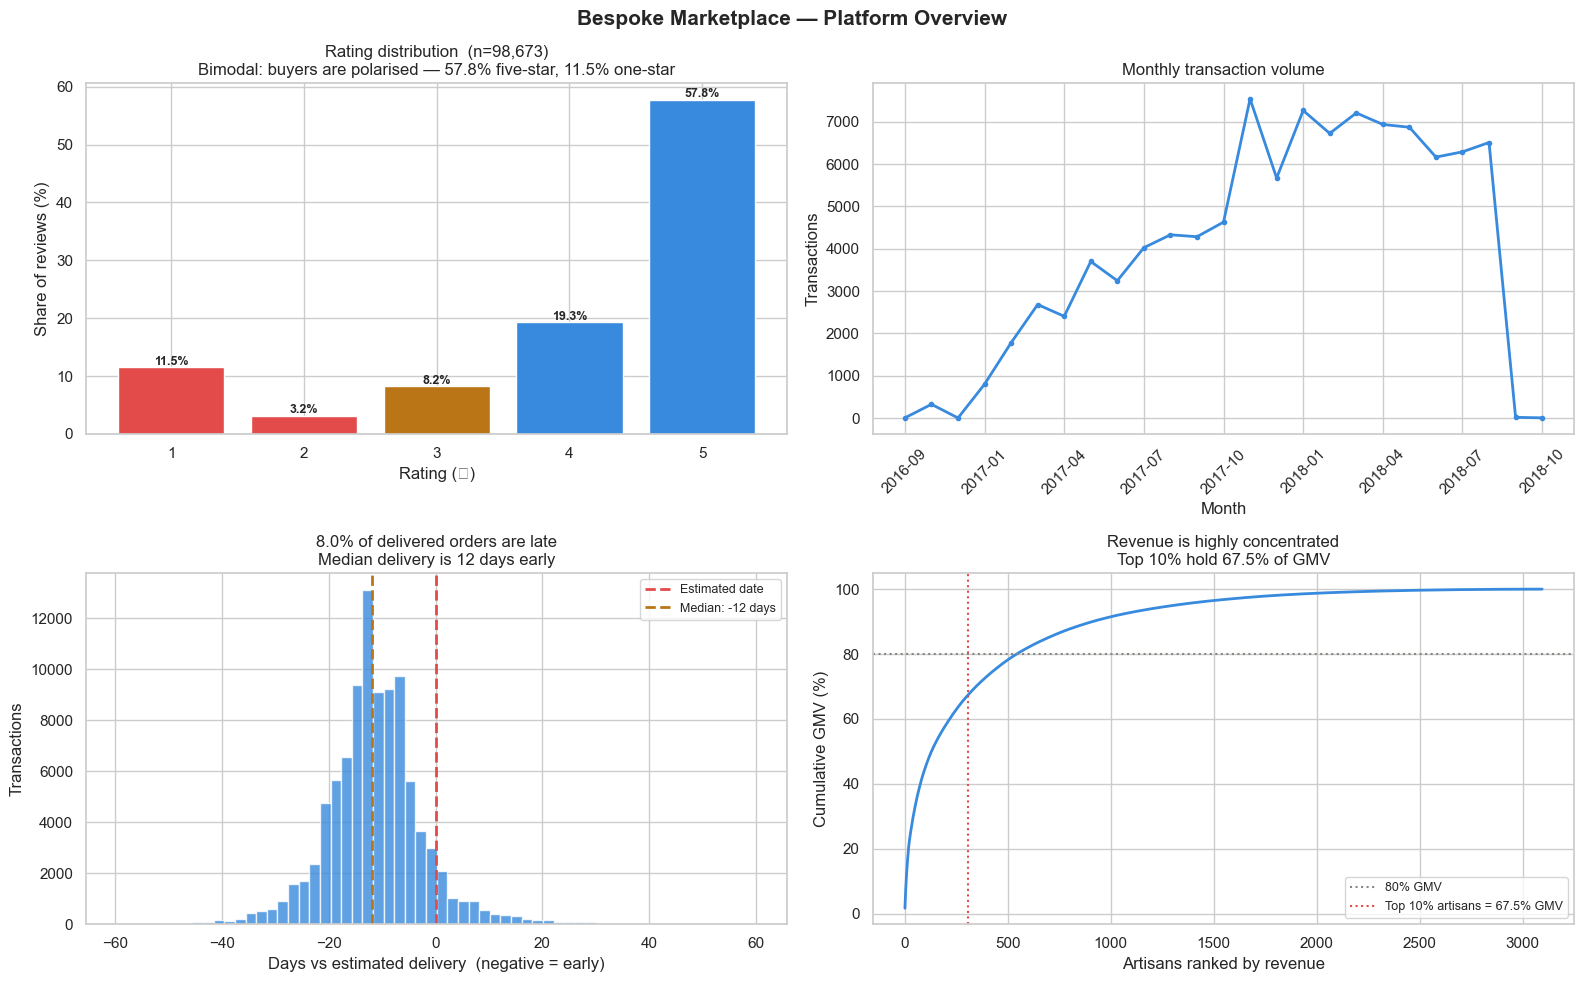

Saved: fig0_platform_overview.png


In [131]:
# Section 5 — Platform overview

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Bespoke Marketplace — Platform Overview', fontsize=15, fontweight='bold')

# A: Rating distribution
ax = axes[0, 0]
rc = feedback['rating_score'].value_counts(normalize=True).sort_index() * 100
bar_cols = [RED, RED, AMBER, BLUE, BLUE]
bars = ax.bar(rc.index.astype(int), rc.values, color=bar_cols, edgecolor='white')
ax.set_xlabel('Rating (★)')
ax.set_ylabel('Share of reviews (%)')
ax.set_title(f'Rating distribution  (n={len(feedback):,})\nBimodal: buyers are polarised — 57.8% five-star, 11.5% one-star')
for bar, v in zip(bars, rc.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.4, f'{v:.1f}%',
            ha='center', fontsize=9, fontweight='bold')

# B: Monthly transaction volume
ax = axes[0, 1]
monthly = (transactions.groupby('purchase_year_month').size()
           .reset_index(name='count').query("purchase_year_month != 'NaT'"))
ax.plot(monthly['purchase_year_month'], monthly['count'],
        color=BLUE, linewidth=2, marker='o', markersize=3)
tick_step = max(1, len(monthly) // 8)
ax.set_xticks(monthly['purchase_year_month'][::tick_step])
ax.tick_params(axis='x', rotation=45)
ax.set_xlabel('Month')
ax.set_ylabel('Transactions')
ax.set_title('Monthly transaction volume')

# C: Delivery delta distribution
ax = axes[1, 0]
delivered = transactions[transactions['transaction_status'] == 'delivered']
d_clean   = delivered['delivery_delta'].dropna()
d_clean   = d_clean[(d_clean >= -60) & (d_clean <= 60)]
ax.hist(d_clean, bins=60, color=BLUE, alpha=0.8, edgecolor='white')
ax.axvline(0,               color=RED,   linestyle='--', linewidth=2, label='Estimated date')
ax.axvline(d_clean.median(), color=AMBER, linestyle='--', linewidth=2,
           label=f'Median: {d_clean.median():.0f} days')
ax.set_xlabel('Days vs estimated delivery  (negative = early)')
ax.set_ylabel('Transactions')
ax.set_title(f'{(d_clean > 0).mean():.1%} of delivered orders are late\n'
             f'Median delivery is {abs(d_clean.median()):.0f} days early')
ax.legend(fontsize=9)

# D: Pareto — revenue concentration
ax = axes[1, 1]
artisan_rev = tx_details.groupby('artisan_id')['price'].sum().sort_values(ascending=False)
cum_pct = (artisan_rev.cumsum() / artisan_rev.sum() * 100).values
ax.plot(range(1, len(cum_pct)+1), cum_pct, color=BLUE, linewidth=2)
top10 = int(len(cum_pct) * 0.10)
ax.axhline(80, color=GRAY, linestyle=':', linewidth=1.5, label='80% GMV')
ax.axvline(top10, color=RED, linestyle=':', linewidth=1.5,
           label=f'Top 10% artisans = {artisan_rev.iloc[:top10].sum()/artisan_rev.sum():.1%} GMV')
ax.set_xlabel('Artisans ranked by revenue')
ax.set_ylabel('Cumulative GMV (%)')
ax.set_title('Revenue is highly concentrated\nTop 10% hold 67.5% of GMV')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(figpath('fig0_platform_overview.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig0_platform_overview.png")


In [133]:
# Section 6 — Artisan feature table + Danger Zone classification

# ── Tenure: days between first and last sale per artisan ─────────────────────
artisan_tenure = (
    line_items.groupby('artisan_id')['purchase_timestamp']
    .agg(['min', 'max'])
    .rename(columns={'min': 'first_sale', 'max': 'last_sale'})
)
artisan_tenure['tenure_days'] = (
    pd.to_datetime(artisan_tenure['last_sale']) -
    pd.to_datetime(artisan_tenure['first_sale'])
).dt.days
artisan_tenure['experienced'] = (artisan_tenure['tenure_days'] >= 365).astype(int)

# ── Artisan feature table ─────────────────────────────────────────────────────
artisan_features = (
    line_items.groupby('artisan_id').agg(
        total_items_sold    = ('transaction_item_id',      'count'),
        unique_transactions = ('transaction_id',           'nunique'),
        total_revenue       = ('price',                    'sum'),
        avg_item_price      = ('price',                    'mean'),
        avg_shipping_cost   = ('shipping_cost',            'mean'),
        avg_rating          = ('rating_score',             'mean'),
        num_ratings         = ('rating_score',             'count'),
        n_1star             = ('rating_score',             lambda x: (x == 1).sum()),
        avg_days_to_ship    = ('days_to_ship',             'mean'),
        avg_days_to_deliver = ('days_to_deliver',          'mean'),
        avg_delivery_delta  = ('delivery_delta',           'mean'),
        pct_late_deliveries = ('delivery_delta',
                               lambda x: (x > 0).sum() / x.count() if x.count() > 0 else np.nan),
        avg_photos          = ('item_photos_qty',          'mean'),
        avg_desc_length     = ('item_description_length',  'mean'),
        unique_categories   = ('category_en',              'nunique'),
        artisan_state       = ('artisan_state',            'first'),
        avg_installments    = ('max_installments',         'mean'),
    ).reset_index()
    .merge(artisan_tenure[['tenure_days', 'experienced']], on='artisan_id', how='left')
)

# Derived columns
artisan_features['pct_1star']   = artisan_features['n_1star'] / artisan_features['num_ratings']
artisan_features['log_revenue'] = np.log1p(artisan_features['total_revenue'])

# Median imputation for sparse columns
fill_cols = ['avg_rating', 'avg_days_to_deliver', 'avg_delivery_delta',
             'pct_late_deliveries', 'avg_shipping_cost', 'avg_desc_length', 'avg_installments']
for col in fill_cols:
    artisan_features[col] = artisan_features[col].fillna(artisan_features[col].median())

# Filter to artisans with >= 5 ratings
artisan_features = artisan_features[artisan_features['num_ratings'] >= 5].copy()

# Tenure summary
n_exp = artisan_features['experienced'].sum()
n_tot = len(artisan_features)
print(f"Artisans with >=5 ratings : {n_tot:,}")
print(f"  Experienced (tenure >=365d): {n_exp:,} ({n_exp/n_tot:.1%})")
print(f"  New         (tenure  <365d): {n_tot-n_exp:,} ({(n_tot-n_exp)/n_tot:.1%})")
print(f"  Median tenure: {artisan_features['tenure_days'].median():.0f} days")

# Satisfaction label
artisan_features['high_satisfaction'] = (artisan_features['avg_rating'] >= 4.0).astype(int)

n_high = artisan_features['high_satisfaction'].sum()
print(f"\n  High satisfaction (>=4.0): {n_high:,} ({n_high/n_tot:.1%})")
print(f"  Low satisfaction (<4.0)  : {n_tot-n_high:,} ({(n_tot-n_high)/n_tot:.1%})")

# ── Danger Zone classification ────────────────────────────────────────────────
rev_median = artisan_features['total_revenue'].median()
artisan_features['high_revenue'] = (artisan_features['total_revenue'] >= rev_median).astype(int)
artisan_features['rev_group']    = np.where(artisan_features['high_revenue'] == 1, 'High Revenue', 'Low Revenue')
artisan_features['sat_group']    = np.where(artisan_features['high_satisfaction'] == 1, 'High Satisfaction', 'Low Satisfaction')

artisan_features['quadrant'] = np.select(
    [
        (artisan_features['high_satisfaction'] == 1) & (artisan_features['high_revenue'] == 1),
        (artisan_features['high_satisfaction'] == 1) & (artisan_features['high_revenue'] == 0),
        (artisan_features['high_satisfaction'] == 0) & (artisan_features['high_revenue'] == 1),
        (artisan_features['high_satisfaction'] == 0) & (artisan_features['high_revenue'] == 0),
    ],
    ['Stars', 'Growth', 'Danger Zone', 'Triage'],
    default='Unknown'
)

danger_artisans = set(artisan_features.loc[artisan_features['quadrant'] == 'Danger Zone', 'artisan_id'])

# ── Quadrant summary table ────────────────────────────────────────────────────
QUADRANT = {
    ('High Satisfaction', 'High Revenue'): 'STARS',
    ('High Satisfaction', 'Low Revenue') : 'GROWTH',
    ('Low Satisfaction',  'High Revenue'): 'DANGER ZONE',
    ('Low Satisfaction',  'Low Revenue') : 'TRIAGE',
}
total_gmv = artisan_features['total_revenue'].sum()
records = []
for sat in ['High Satisfaction', 'Low Satisfaction']:
    for rev in ['Low Revenue', 'High Revenue']:
        subset = artisan_features[(artisan_features['sat_group'] == sat) & (artisan_features['rev_group'] == rev)]
        records.append({
            'Quadrant'           : QUADRANT[(sat, rev)],
            'Artisans'           : len(subset),
            'GMV ($)'            : f"${subset['total_revenue'].sum():>12,.0f}",
            'GMV share'          : f"{subset['total_revenue'].sum() / total_gmv:.1%}",
            'Avg rating'         : f"{subset['avg_rating'].mean():.2f}",
            'Avg revenue/artisan': f"${subset['total_revenue'].mean():>8,.0f}",
        })

print(f"\n{'=' * 65}")
print(f"2x2 Quadrant Summary  (revenue median split: ${rev_median:,.0f})")
print('=' * 65)
print(pd.DataFrame(records).set_index('Quadrant').to_string())

# ── Revenue at Risk ───────────────────────────────────────────────────────────
dz = artisan_features[artisan_features['quadrant'] == 'Danger Zone']
print(f"\n{'=' * 65}")
print(f"Revenue at Risk — Danger Zone ({len(dz):,} artisans)")
print('=' * 65)
print(f"  Total DZ GMV: R${dz['total_revenue'].sum():,.0f}  ({dz['total_revenue'].sum()/total_gmv:.1%} of platform GMV)")
print(f"\n  Severity tiers within DZ (by 1-star rate):")
for thresh, label in [(0.10,'Borderline (>=10% 1-star)'), (0.20,'Moderate (>=20%)'), (0.30,'Severe (>=30%)')]:
    sub = dz[dz['pct_1star'] >= thresh]
    rar = sub['total_revenue'].sum()
    print(f"    {label}: {len(sub):>3} artisans  |  R${rar:,.0f}  ({rar/total_gmv:.1%} of GMV)")


Artisans with >=5 ratings : 1,890
  Experienced (tenure >=365d): 535 (28.3%)
  New         (tenure  <365d): 1,355 (71.7%)
  Median tenure: 236 days

  High satisfaction (>=4.0): 1,217 (64.4%)
  Low satisfaction (<4.0)  : 673 (35.6%)

2x2 Quadrant Summary  (revenue median split: $2,164)
             Artisans        GMV ($) GMV share Avg rating Avg revenue/artisan
Quadrant                                                                     
GROWTH            619  $     561,709      4.3%       4.47           $     907
STARS             598  $   8,058,124     61.5%       4.30           $  13,475
TRIAGE            326  $     307,126      2.3%       3.33           $     942
DANGER ZONE       347  $   4,186,085     31.9%       3.61           $  12,064

Revenue at Risk — Danger Zone (347 artisans)
  Total DZ GMV: R$4,186,085  (31.9% of platform GMV)

  Severity tiers within DZ (by 1-star rate):
    Borderline (>=10% 1-star): 329 artisans  |  R$4,087,525  (31.2% of GMV)
    Moderate (>=20%): 14

In [132]:
# Section 7 — Satisfaction x Revenue correlation analysis

r_sat  = artisan_features['avg_rating'].corr(artisan_features['log_revenue'])
r_late = artisan_features['pct_late_deliveries'].corr(artisan_features['log_revenue'])
print(f"Corr(avg_rating,       log_revenue): {r_sat:.3f}")
print(f"Corr(pct_late,         log_revenue): {r_late:.3f}")
print("Revenue and satisfaction are nearly independent dimensions.")
print("Revenue and delivery performance are nearly independent dimensions.")

Corr(avg_rating,       log_revenue): -0.022
Corr(pct_late,         log_revenue): 0.011
Revenue and satisfaction are nearly independent dimensions.
Revenue and delivery performance are nearly independent dimensions.


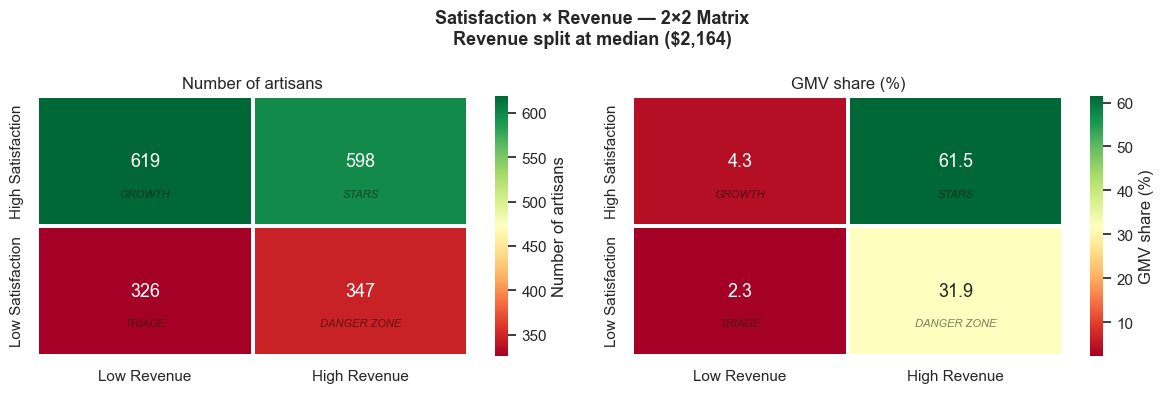

In [134]:
# Section 7a — Satisfaction x Revenue: 2x2 matrix
# Danger zone if low satisfaction AND in the top revenue quartile — these sellers have a large GMV footprint but poor buyer experience.

rev_median = artisan_features['total_revenue'].median()
artisan_features['rev_group'] = np.where(
    artisan_features['total_revenue'] >= rev_median, 'High Revenue', 'Low Revenue'
)
artisan_features['sat_group'] = np.where(
    artisan_features['high_satisfaction'] == 1, 'High Satisfaction', 'Low Satisfaction'
)

total_gmv = artisan_features['total_revenue'].sum()

matrix_n = artisan_features.pivot_table(
    index='sat_group', columns='rev_group',
    values='artisan_id', aggfunc='count'
)
matrix_gmv_pct = artisan_features.pivot_table(
    index='sat_group', columns='rev_group',
    values='total_revenue', aggfunc='sum'
).div(total_gmv) * 100

# Quadrant labels for annotation
QUADRANT = {
    ('High Satisfaction', 'High Revenue'): 'STARS',
    ('High Satisfaction', 'Low Revenue'):  'GROWTH',
    ('Low Satisfaction',  'High Revenue'): 'DANGER ZONE',
    ('Low Satisfaction',  'Low Revenue'):  'TRIAGE',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Satisfaction × Revenue — 2×2 Matrix\n'
             f'Revenue split at median (${rev_median:,.0f})',
             fontsize=13, fontweight='bold')

row_order = ['High Satisfaction', 'Low Satisfaction']
col_order = ['Low Revenue', 'High Revenue']

for ax, matrix, fmt, title in zip(
    axes,
    [matrix_n.loc[row_order, col_order],
     matrix_gmv_pct.loc[row_order, col_order]],
    ['d', '.1f'],
    ['Number of artisans', 'GMV share (%)']
):
    sns.heatmap(matrix, annot=True, fmt=fmt, cmap='RdYlGn', ax=ax,
                linewidths=1.5, linecolor='white',
                cbar_kws={'label': title}, annot_kws={'size': 13})
    # Overlay quadrant names
    for (row, col), name in QUADRANT.items():
        if row in row_order and col in col_order:
            r, c = row_order.index(row), col_order.index(col)
            ax.text(c + 0.5, r + 0.75, name, ha='center', va='center',
                    fontsize=8, color='black', alpha=0.5, fontstyle='italic')
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig(figpath('fig_2x2_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

Metric                        Danger Zone   Rest of Platform       Gap  Significance
─────────────────────────────────────────────────────────────────────────────────────
  Avg days to deliver           14.4 days          11.6 days  +2.9 days  p<0.001
  Avg days to ship               4.5 days           3.2 days  +1.4 days  p<0.001
  Avg delivery delta           -10.8 days         -11.7 days  +0.9 days  p<0.001
  % late deliveries                 11.4%               7.4%     +4.0%  p<0.001
  Avg rating                         3.61               4.16     -0.55  p<0.001
  Avg item price (R$)            R$222.70           R$142.10  +R$80.60  p<0.001
  Avg listing photos                  2.2                2.1      +0.1  n.s.  
  Avg description length        862 chars          842 chars  +20 chars  n.s.  
  Avg transactions                   95.9               41.8     +54.1  p<0.001
  Unique categories                   3.5                2.5      +1.0  p<0.001
  % experienced (>=1yr)    

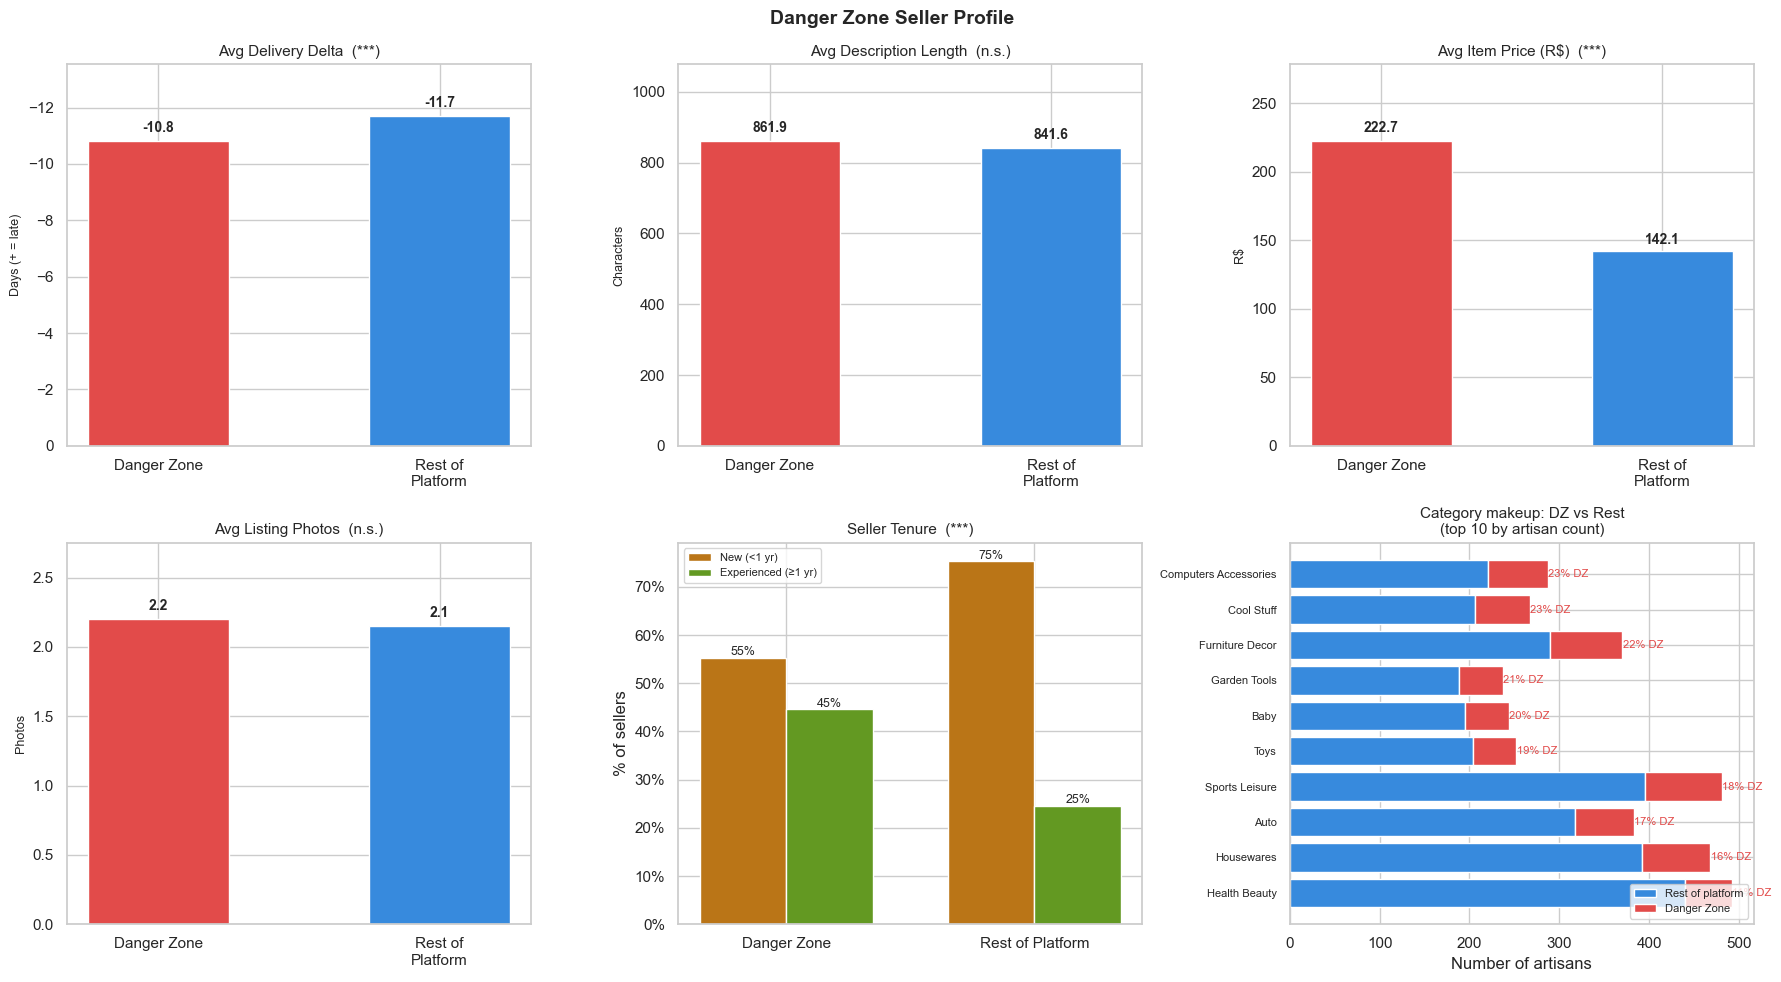

Saved: fig_dz_seller_profile.png


In [135]:
# Section 7b — Danger Zone seller profile + logistic regression
# Compares DZ sellers vs rest of platform on dimensions a buyer actually experiences:
# delivery speed/reliability, listing quality, price, tenure, and category makeup.

import matplotlib.ticker as mticker
from scipy import stats

dz_af   = artisan_features[artisan_features['quadrant'] == 'Danger Zone'].copy()
rest_af = artisan_features[artisan_features['quadrant'] != 'Danger Zone'].copy()

# experienced column already built in Section 6 (tenure_days >= 365)



# ── Buyer-facing metrics: DZ vs rest, with Mann-Whitney U p-values ────────────
# Mann-Whitney (non-parametric): artisan-level distributions are right-skewed.
profile_metrics = {
    'Avg days to deliver'   : ('avg_days_to_deliver',  '{:.1f} days'),
    'Avg days to ship'      : ('avg_days_to_ship',     '{:.1f} days'),
    'Avg delivery delta'    : ('avg_delivery_delta',   '{:.1f} days'),
    '% late deliveries'     : ('pct_late_deliveries',  '{:.1%}'),
    'Avg rating'            : ('avg_rating',           '{:.2f}'),
    'Avg item price (R$)'   : ('avg_item_price',       'R${:.2f}'),
    'Avg listing photos'    : ('avg_photos',           '{:.1f}'),
    'Avg description length': ('avg_desc_length',      '{:.0f} chars'),
    'Avg transactions'      : ('unique_transactions',  '{:.1f}'),
    'Unique categories'     : ('unique_categories',    '{:.1f}'),
    '% experienced (>=1yr)' : ('experienced',          '{:.1%}'),
}

def fmt_p(p):
    if p < 0.001: return 'p<0.001'
    if p < 0.01:  return 'p<0.01 '
    if p < 0.05:  return 'p<0.05 '
    return 'n.s.  '

print(f"{'Metric':<26} {'Danger Zone':>14} {'Rest of Platform':>18}  {'Gap':>8}  {'Significance'}")
print("─" * 85)
for label, (col, fmt) in profile_metrics.items():
    dz_vals   = dz_af[col].dropna()
    rest_vals = rest_af[col].dropna()
    dz_mean   = dz_vals.mean()
    rest_mean = rest_vals.mean()
    gap       = dz_mean - rest_mean
    _, p      = stats.mannwhitneyu(dz_vals, rest_vals, alternative='two-sided')
    gap_str   = ('+' if gap > 0 else '') + fmt.format(gap)
    print(f"  {label:<24} {fmt.format(dz_mean):>14} {fmt.format(rest_mean):>18}  {gap_str:>8}  {fmt_p(p)}")

# ── Category breakdown for panel 6 ───────────────────────────────────────────
dz_ids = set(dz_af['artisan_id'])

cat_artisan = (
    line_items[line_items['category_en'].notna()]
    .groupby(['category_en', 'artisan_id'])
    .size()
    .reset_index()[['category_en', 'artisan_id']]
)
cat_artisan['is_dz'] = cat_artisan['artisan_id'].isin(dz_ids)

cat_counts = (
    cat_artisan.groupby(['category_en', 'is_dz'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={True: 'dz', False: 'non_dz'})
)
cat_counts['total']  = cat_counts['dz'] + cat_counts['non_dz']
cat_counts['dz_pct'] = cat_counts['dz'] / cat_counts['total']

top_cats   = cat_counts.nlargest(10, 'total').sort_values('dz_pct')
cat_labels = [c.replace('_', ' ').title() for c in top_cats.index]

# ── Tenure breakdown for panel 5 ─────────────────────────────────────────────
tenure_dz   = dz_af['experienced'].value_counts(normalize=True).reindex([0,1], fill_value=0) * 100
tenure_rest = rest_af['experienced'].value_counts(normalize=True).reindex([0,1], fill_value=0) * 100
_, p_tenure = stats.mannwhitneyu(dz_af['experienced'], rest_af['experienced'], alternative='two-sided')
sig_tenure  = '***' if p_tenure < 0.001 else ('**' if p_tenure < 0.01 else ('*' if p_tenure < 0.05 else 'n.s.'))

# ── Visualisation: 2×3 grid ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Danger Zone Seller Profile",
             fontsize=14, fontweight='bold')

panels = [
    ('avg_delivery_delta',  'Avg Delivery Delta',     'Days (+ = late)', False),
    ('avg_desc_length',     'Avg Description Length', 'Characters',  False),
    ('avg_item_price',      'Avg Item Price (R$)',    'R$',           False),
    ('avg_photos',          'Avg Listing Photos',     'Photos',       False),
]

for ax, (col, title, ylabel, is_pct) in zip(axes.flat, panels):
    dz_val   = dz_af[col].mean()
    rest_val = rest_af[col].mean()
    _, p     = stats.mannwhitneyu(dz_af[col].dropna(), rest_af[col].dropna(), alternative='two-sided')
    sig      = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))

    bars = ax.bar(['Danger Zone', 'Rest of\nPlatform'], [dz_val, rest_val],
                  color=[RED, BLUE], width=0.5, edgecolor='white')
    for bar, val in zip(bars, [dz_val, rest_val]):
        lbl = f'{val:.1%}' if is_pct else f'{val:.1f}'
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                lbl, ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(f'{title}  ({sig})', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_ylim(0, max(dz_val, rest_val) * 1.25)
    if is_pct:
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

# Panel 5 — Tenure: % experienced vs new, DZ vs rest
ax = axes[1, 1]
x = np.arange(2)
w = 0.35
ax.bar(x - w/2, [tenure_dz[0],   tenure_rest[0]],   w, color=AMBER, label='New (<1 yr)')
ax.bar(x + w/2, [tenure_dz[1],   tenure_rest[1]],   w, color=GREEN, label='Experienced (≥1 yr)')
ax.set_xticks(x)
ax.set_xticklabels(['Danger Zone', 'Rest of Platform'])
ax.set_ylabel('% of sellers')
ax.set_title(f'Seller Tenure  ({sig_tenure})', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
for i, (dz_v, rest_v) in enumerate([(tenure_dz[0], tenure_rest[0]),
                                     (tenure_dz[1], tenure_rest[1])]):
    ax.text(0 - w/2 + i*w, dz_v   + 0.5, f'{dz_v:.0f}%',   ha='center', fontsize=9)
    ax.text(1 - w/2 + i*w, rest_v + 0.5, f'{rest_v:.0f}%', ha='center', fontsize=9)
ax.legend(fontsize=8)

# Panel 6 — horizontal stacked bar: DZ vs non-DZ artisan makeup by category
ax = axes[1, 2]
y = np.arange(len(top_cats))
ax.barh(y, top_cats['non_dz'], color=BLUE, label='Rest of platform')
ax.barh(y, top_cats['dz'],     color=RED,  label='Danger Zone', left=top_cats['non_dz'])
for i, (_, row) in enumerate(top_cats.iterrows()):
    ax.text(row['total'] + 0.5, i, f"{row['dz_pct']:.0%} DZ",
            va='center', fontsize=8, color=RED)
ax.set_yticks(y)
ax.set_yticklabels(cat_labels, fontsize=8)
ax.set_xlabel('Number of artisans')
ax.set_title('Category makeup: DZ vs Rest\n(top 10 by artisan count)', fontsize=11)
ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig(figpath('fig_dz_seller_profile.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_dz_seller_profile.png")


DZ artisans: 347 / 1890 sellers  (18.4% of artisans)
DZ 1-star reviews: 6,897 / 14,137  (48.8% of all 1-star reviews)
DZ GMV: R$4,186,085  (31.9% of platform GMV)

Danger Zone has disproportionately high share of 1-star reviews and GMV.


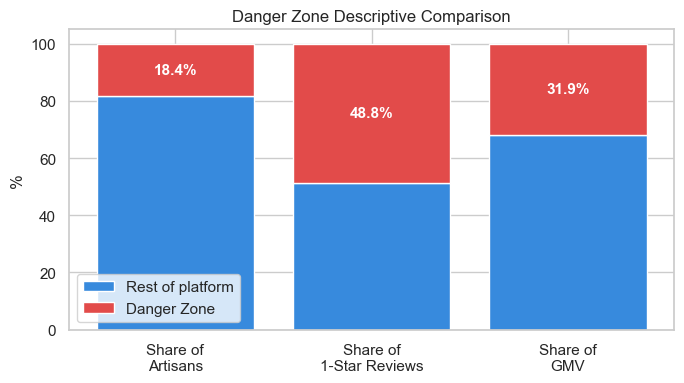

Saved: fig_dz_1star_share.png


In [136]:
# Section 7c — Danger Zone: share of sellers, 1-star reviews, and GMV

dz = artisan_features[artisan_features['quadrant'] == 'Danger Zone']
total_gmv = artisan_features['total_revenue'].sum()

# Proportion of artisans that are DZ
dz_pct_sellers = len(dz) / len(artisan_features)

# Proportion of all 1-star reviews that belong to DZ artisans
dz_artisan_ids = set(dz['artisan_id'])
dz_1star = line_items[
    line_items['artisan_id'].isin(dz_artisan_ids) & (line_items['rating_score'] == 1)
].shape[0]
total_1star = (line_items['rating_score'] == 1).sum()
dz_pct_1star = dz_1star / total_1star

print(f"DZ artisans: {len(dz)} / {len(artisan_features)} sellers  ({dz_pct_sellers:.1%} of artisans)")
print(f"DZ 1-star reviews: {dz_1star:,} / {total_1star:,}  ({dz_pct_1star:.1%} of all 1-star reviews)")
print(f"DZ GMV: R${dz['total_revenue'].sum():,.0f}  ({dz['total_revenue'].sum()/total_gmv:.1%} of platform GMV)")

# Bar chart: % of sellers vs % of 1-star reviews
fig, ax = plt.subplots(figsize=(7, 4))
categories = ['Share of\nArtisans', 'Share of\n1-Star Reviews', 'Share of\nGMV']
dz_vals  = [dz_pct_sellers * 100,
            dz_pct_1star   * 100,
            dz['total_revenue'].sum() / total_gmv * 100]
rest_vals = [100 - v for v in dz_vals]

x = range(len(categories))
bars_rest = ax.bar(x, rest_vals, color=BLUE,  label='Rest of platform')
bars_dz   = ax.bar(x, dz_vals,  color=RED,   label='Danger Zone', bottom=rest_vals)

ax.set_xticks(list(x))
ax.set_xticklabels(categories)
ax.set_ylabel('%')
ax.set_title('Danger Zone Descriptive Comparison')
ax.legend()
for bar, v in zip(bars_dz, dz_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}%', ha='center', va='center', fontsize=11, fontweight='bold', color='white')

print(f"\nDanger Zone has disproportionately high share of 1-star reviews and GMV.")
plt.tight_layout()
plt.savefig(figpath('fig_dz_1star_share.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_dz_1star_share.png")

1-star reviews: 5,521 DZ  |  5,230 Non-DZ
Translation: OFF — Portuguese keyword matching

  Theme                             DZ%    Non-DZ%      Diff
  ----------------------------------------------------------
  Delivery / Late Arrival         27.0%      28.5%     -1.5%
  Never Received                  25.8%      26.9%     -1.1%
  Product Quality                  9.1%       7.9%     +1.2%
  Seller / Service                 3.6%       4.1%     -0.6%
  Refund / Money                   3.5%       2.4%     +1.1%
  Packaging                        1.6%       1.3%     +0.3%
  Unclassified                    29.4%      28.9%     +0.6%


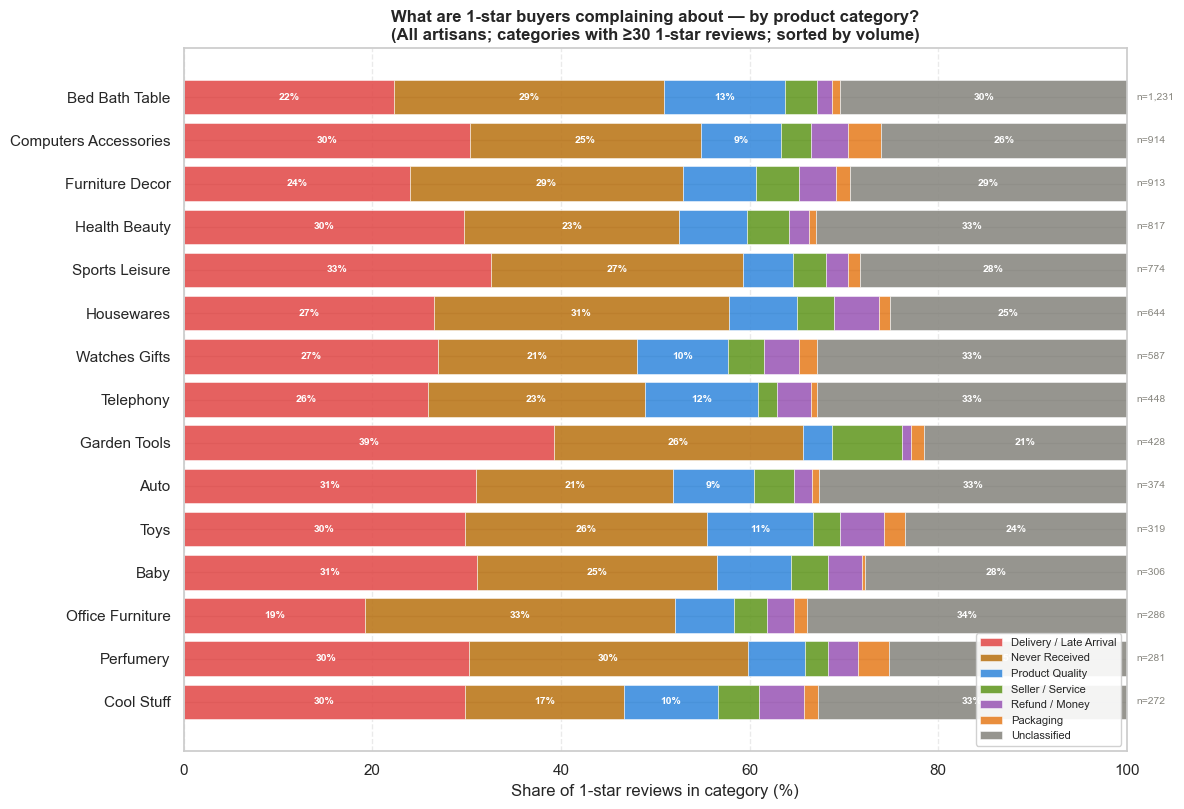

Saved: fig_category_complaint_themes.png


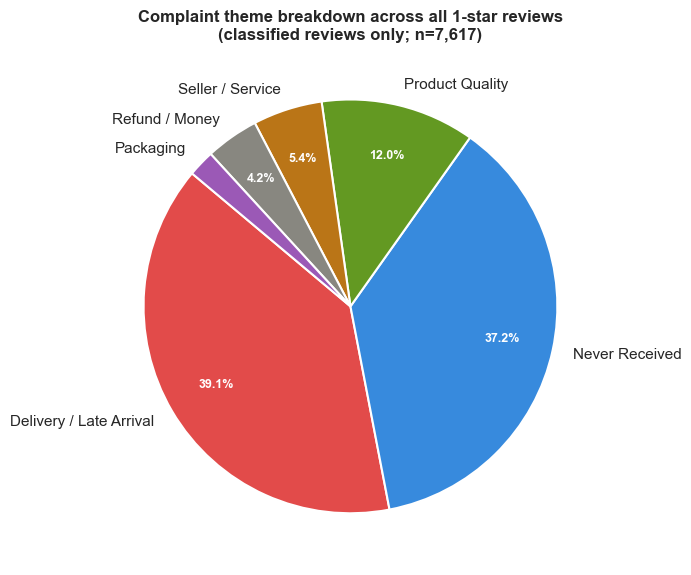

Saved: fig_complaint_categories.png


In [ ]:
# Section 7d — Complaint theme extraction
#
# TRANSLATE_REVIEWS = False  → classify directly on Portuguese text (fast, no API)
# TRANSLATE_REVIEWS = True   → translate via Google first, cache results locally,
#                              then classify on English text (requires deep-translator)

import unicodedata, re, os, time, json as _json

TRANSLATE_REVIEWS = False   # flip to True if deep-translator is installed
SHIP_THRESHOLD    = 3       # days — artisan vs carrier fault boundary

# ── Complaint theme keyword sets (bilingual: PT roots + EN after translation) ──
REVIEW_THEMES = {
    'Delivery / Late Arrival': {
        'delivery','delivered','arrived','arrive','late','delayed','delay',
        'shipping','shipped','courier','carrier','transit','deadline','weeks',
        'entrega','atrasou','atrasado','atraso','prazo','correios','transportadora',
        'dias','semanas','chegou','despachado','demorou','demora',
    },
    'Never Received': {
        'received','receive','came','missing','tracking','lost','stolen','never',
        'recebi','perdido','nunca','rastreamento','nao chegou','nao veio',
        'nao recebi','sumiu','extraviado','nao apareceu',
    },
    'Product Quality': {
        'quality','broken','damaged','defective','wrong','poor','bad','fake',
        'different','size','color','smell','dirty','scratched','incomplete',
        'qualidade','quebrado','danificado','errado','diferente','tamanho',
        'cor','usado','incompleto','defeito','descricao','nao funciona',
        'produto errado','item errado','veio errado',
    },
    'Seller / Service': {
        'response','ignored','support','service','seller','rude','fraud','scam',
        'communication','contact','respond','unprofessional',
        'vendedor','resposta','contato','ignorou','atendimento','fraude',
    },
    'Refund / Money': {
        'refund','money','return','charge','paid','price','expensive','dispute',
        'reembolso','dinheiro','devolucao','cobrado','pagamento','preco',
    },
    'Packaging': {
        'package','packaging','box','wrapped','bag','crushed','smashed','torn',
        'embalagem','caixa','pacote','amassado','rasgado',
    },
}

def _normalize(text):
    return unicodedata.normalize('NFKD', str(text)).encode('ascii', 'ignore').decode()

def _classify(text):
    if not isinstance(text, str) or not text.strip():
        return 'Unclassified'
    tokens = set(re.sub(r"[^a-z\s\'-]", ' ', _normalize(text).lower()).split())
    scores = {t: len(tokens & kws) for t, kws in REVIEW_THEMES.items()}
    best   = max(scores.values())
    return 'Unclassified' if best == 0 else max(scores, key=scores.get)

# ── Build 1-star review DataFrame ─────────────────────────────────────────────
ones_raw = (
    line_items[line_items['rating_score'] == 1]
    .merge(feedback[['transaction_id','feedback_message']], on='transaction_id', how='left')
    .dropna(subset=['feedback_message'])
)
ones_raw = ones_raw[ones_raw['feedback_message'].str.strip() != ''].copy()

_dz_ids    = danger_artisans
_all_ids   = set(artisan_features['artisan_id'])
_nondz_ids = _all_ids - _dz_ids
ones_raw['group'] = ones_raw['artisan_id'].map(
    lambda x: 'Danger Zone' if x in _dz_ids
              else ('Non-DZ' if x in _nondz_ids else None)
)
ones_raw = ones_raw[ones_raw['group'].notna()].copy()

# ── Optional translation with local cache ─────────────────────────────────────
if TRANSLATE_REVIEWS:
    from deep_translator import GoogleTranslator
    _cache_path = 'translation_cache.json'
    _cache = {}
    if os.path.exists(_cache_path):
        with open(_cache_path) as _f:
            _cache = _json.load(_f)
        print(f"Cache loaded: {len(_cache):,} existing translations")
    _translator = GoogleTranslator(source='auto', target='en')
    _to_do = [t for t in ones_raw['feedback_message'].unique() if t not in _cache]
    print(f"Translating {len(_to_do):,} new texts...")
    for _i, _txt in enumerate(_to_do):
        try:    _cache[_txt] = _translator.translate(str(_txt)[:4999])
        except: _cache[_txt] = _txt
        if (_i + 1) % 100 == 0:
            print(f"  {_i+1:,}/{len(_to_do):,}", flush=True)
        time.sleep(0.15)
    if _to_do:
        with open(_cache_path, 'w') as _f:
            _json.dump(_cache, _f, ensure_ascii=False)
        print(f"Cache saved → translation_cache.json")
    ones_raw['review_text'] = ones_raw['feedback_message'].map(lambda t: _cache.get(t, t))
else:
    ones_raw['review_text'] = ones_raw['feedback_message']

# ── Classify themes + fault attribution ───────────────────────────────────────
ones_raw['complaint_theme'] = ones_raw['review_text'].apply(_classify)
ones_raw['fault'] = ones_raw.apply(
    lambda r: ('Artisan (slow to ship)'   if pd.notna(r.get('days_to_ship'))  and r.get('days_to_ship')  > SHIP_THRESHOLD
               else 'Carrier (late in transit)' if pd.notna(r.get('delivery_delta')) and r.get('delivery_delta') > 0
               else 'Unknown'), axis=1
)

ones_dz    = ones_raw[ones_raw['group'] == 'Danger Zone'].copy()
ones_nondz = ones_raw[ones_raw['group'] == 'Non-DZ'].copy()

# ── Print DZ vs Non-DZ theme summary ─────────────────────────────────────────
THEME_ORDER = [
    'Delivery / Late Arrival', 'Never Received', 'Product Quality',
    'Seller / Service', 'Refund / Money', 'Packaging', 'Unclassified',
]
dz_themes = ones_dz['complaint_theme'].value_counts(normalize=True) * 100
nd_themes = ones_nondz['complaint_theme'].value_counts(normalize=True) * 100

print(f"1-star reviews: {len(ones_dz):,} DZ  |  {len(ones_nondz):,} Non-DZ")
print(f"Translation: {'ON' if TRANSLATE_REVIEWS else 'OFF — Portuguese keyword matching'}\n")
print(f"  {'Theme':<28}  {'DZ%':>7}  {'Non-DZ%':>9}  {'Diff':>8}")
print("  " + "-"*58)
for t in THEME_ORDER:
    dz_p, nd_p = dz_themes.get(t, 0), nd_themes.get(t, 0)
    flag = "  ◄" if abs(dz_p - nd_p) >= 5 else ""
    print(f"  {t:<28}  {dz_p:>6.1f}%  {nd_p:>8.1f}%  {dz_p-nd_p:>+7.1f}%{flag}")

# ── Stacked bar: complaint themes by product category ─────────────────────────
THEME_PALETTE = {
    'Delivery / Late Arrival': RED,
    'Never Received':          AMBER,
    'Product Quality':         BLUE,
    'Seller / Service':        GREEN,
    'Refund / Money':          '#9B59B6',
    'Packaging':               '#E67E22',
    'Unclassified':            GRAY,
}

all_ones = pd.concat([ones_dz, ones_nondz], ignore_index=True)
all_ones['category_clean'] = (all_ones['category_en']
    .fillna('unknown').astype(str)
    .str.replace('_', ' ').str.title())

cat_counts  = all_ones['category_clean'].value_counts()
valid_cats  = cat_counts[cat_counts >= 30].index
plot_df     = all_ones[all_ones['category_clean'].isin(valid_cats)]

pivot = (plot_df.groupby(['category_clean','complaint_theme'])
                .size().unstack(fill_value=0))
present_themes = [t for t in THEME_ORDER if t in pivot.columns]
pivot_pct = pivot[present_themes].div(pivot[present_themes].sum(axis=1), axis=0) * 100
pivot_pct = pivot_pct.loc[cat_counts[valid_cats].sort_values(ascending=False).index].head(15)

fig, ax = plt.subplots(figsize=(12, max(5, len(pivot_pct) * 0.55)))
left = pd.Series([0.0] * len(pivot_pct), index=pivot_pct.index)

for theme in present_themes:
    vals  = pivot_pct[theme]
    color = THEME_PALETTE.get(theme, GRAY)
    bars  = ax.barh(pivot_pct.index, vals, left=left,
                    color=color, alpha=0.88, edgecolor='white', linewidth=0.4,
                    label=theme)
    for bar, v, l in zip(bars, vals, left):
        if v >= 8:
            ax.text(l + v/2, bar.get_y() + bar.get_height()/2,
                    f'{v:.0f}%', ha='center', va='center',
                    fontsize=7.5, color='white', fontweight='bold')
    left = left + vals

ax.set_xlim(0, 100)
ax.set_xlabel('Share of 1-star reviews in category (%)')
ax.set_title('What are 1-star buyers complaining about — by product category?\n'
             '(All artisans; categories with ≥30 1-star reviews; sorted by volume)',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=8, framealpha=0.9)
ax.invert_yaxis()
ax.set_axisbelow(True)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
for i, cat in enumerate(pivot_pct.index):
    ax.text(101, i, f'n={cat_counts[cat]:,}', va='center', fontsize=7.5, color=GRAY)

plt.tight_layout()
plt.savefig(figpath('fig_category_complaint_themes.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_category_complaint_themes.png')

# ── Pie chart: overall complaint theme breakdown across all 1-star reviews ─────
theme_counts = ones_raw['complaint_theme'].value_counts()
theme_counts = theme_counts[theme_counts.index != 'Unclassified']

THEME_COLORS = [RED, BLUE, GREEN, AMBER, GRAY, '#9B59B6']

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    theme_counts.values,
    labels=theme_counts.index,
    autopct=lambda p: f'{p:.1f}%' if p >= 4 else '',
    colors=THEME_COLORS[:len(theme_counts)],
    startangle=140,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
)
for t in autotexts:
    t.set_fontsize(9)
    t.set_fontweight('bold')
    t.set_color('white')

ax.set_title(
    'Complaint theme breakdown across all 1-star reviews\n'
    f'(classified reviews only; n={theme_counts.sum():,})',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(figpath('fig_complaint_categories.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_complaint_categories.png')


Regression dataset: 94,504 transactions
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.121
Model:                            OLS   Adj. R-squared:                  0.121
Method:                 Least Squares   F-statistic:                     1441.
Date:                Mon, 04 May 2026   Prob (F-statistic):               0.00
Time:                        19:19:21   Log-Likelihood:            -1.5159e+05
No. Observations:               94504   AIC:                         3.032e+05
Df Residuals:                   94494   BIC:                         3.033e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

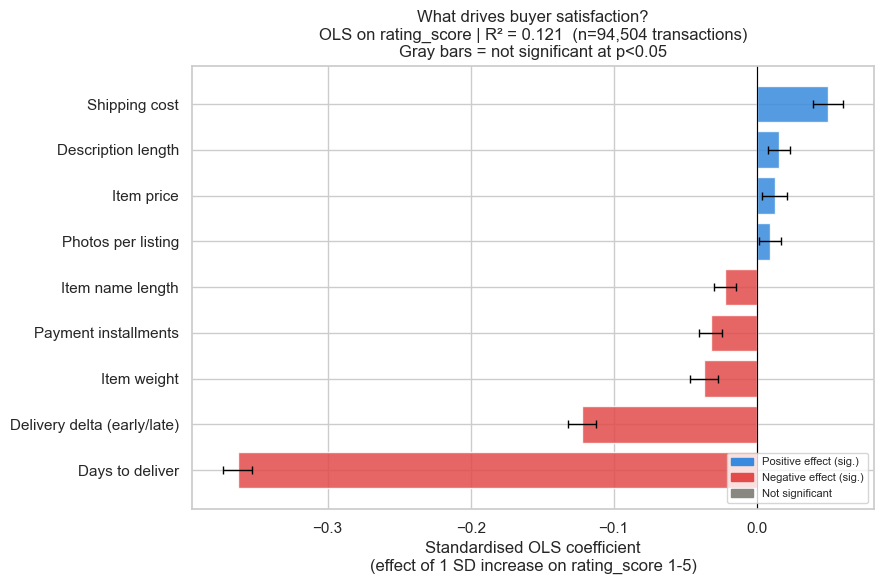

Saved: fig2_ols_satisfaction_drivers.png

OLS R² = 0.1207 — explains 12.1% of variance in rating_score
R² is modest but meaningful at transaction level — individual ratings are noisy.
Coefficients show direction and magnitude of each lever across ~99K transactions.

Payment installments coef: -0.0321 (p=0.0000, significant)
  => Higher-installment (more expensive) purchases rate lower — consistent
     with the weight/price-tier expectations gap found in SHAP.


In [ ]:
# Section 8 — OLS regression: drivers of buyer satisfaction
# Dependent variable : rating_score (1-5, treated as continuous for OLS)
# Unit of analysis   : individual transaction (not artisan aggregate)
# All predictors are standardised (mean=0, sd=1) so coefficients are directly comparable.
#
# Why OLS here rather than ordinal logit?
#   OLS gives interpretable, directly comparable coefficients with no distributional
#   assumptions on the response. Rating_score is effectively used as a continuous
#   satisfaction index at this scale (99K transactions). We note the limitation that
#   it is technically ordinal.

reg_df = (
    transactions[['transaction_id', 'delivery_delta', 'days_to_deliver', 'days_to_ship']]
    .merge(feedback[['transaction_id', 'rating_score']], on='transaction_id', how='inner')
    .merge(tx_details.groupby('transaction_id').agg(
               price         = ('price',          'mean'),
               shipping_cost = ('shipping_cost',  'mean'),
           ).reset_index(), on='transaction_id', how='left')
    .merge(line_items.groupby('transaction_id').agg(
               item_photos_qty        = ('item_photos_qty',        'mean'),
               item_weight_g          = ('item_weight_g',          'mean'),
               item_name_length       = ('item_name_length',       'mean'),
               item_description_length= ('item_description_length','mean'),
               max_installments       = ('max_installments',       'first'),
           ).reset_index(), on='transaction_id', how='left')
    .dropna(subset=['rating_score'])
)

PREDICTORS = [
    'delivery_delta',          # days early/late vs estimate — did it arrive when promised?
    'days_to_deliver',         # absolute delivery time — how long did the buyer wait?
    'price',                   # item price — proxy for buyer expectations
    'shipping_cost',           # cost of shipping charged to buyer
    'item_photos_qty',         # listing quality signal
    'item_weight_g',           # item complexity / fragility proxy
    'item_name_length',        # listing completeness
    'item_description_length', # listing completeness — sets accurate expectations
    'max_installments',        # payment behaviour (higher = larger purchases)
]

reg_df = reg_df.dropna(subset=PREDICTORS)
print(f"Regression dataset: {len(reg_df):,} transactions")

# Standardise all predictors so coefficients are comparable
scaler = StandardScaler()
X_reg  = pd.DataFrame(scaler.fit_transform(reg_df[PREDICTORS]),
                      columns=PREDICTORS, index=reg_df.index)
y_reg  = reg_df['rating_score'].values

X_reg_const = sm.add_constant(X_reg)
ols_model   = sm.OLS(y_reg, X_reg_const).fit()
print(ols_model.summary())

# Coefficient plot (significant predictors only, p < 0.05)
coef_df = pd.DataFrame({
    'feature': PREDICTORS,
    'coef'   : ols_model.params[1:].values,
    'pval'   : ols_model.pvalues[1:].values,
    'ci_lo'  : ols_model.conf_int().iloc[1:, 0].values,
    'ci_hi'  : ols_model.conf_int().iloc[1:, 1].values,
}).sort_values('coef')

LABEL_MAP_REG = {
    'delivery_delta':           'Delivery delta (early/late)',
    'days_to_deliver':          'Days to deliver',
    'days_to_ship':             'Days to ship',
    'price':                    'Item price',
    'shipping_cost':            'Shipping cost',
    'item_photos_qty':          'Photos per listing',
    'item_weight_g':            'Item weight',
    'item_description_length':  'Description length',
    'item_name_length':         'Item name length',
    'max_installments':         'Payment installments',
}
coef_df['label'] = coef_df['feature'].map(LABEL_MAP_REG).fillna(coef_df['feature'])
coef_df['sig']       = coef_df['pval'] < 0.05
coef_df['bar_color'] = coef_df.apply(
    lambda r: (BLUE if r['coef'] > 0 else RED) if r['sig'] else GRAY, axis=1
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(coef_df['label'], coef_df['coef'],
        color=coef_df['bar_color'], alpha=0.85, edgecolor='white')
# 95% confidence intervals
ax.errorbar(coef_df['coef'], range(len(coef_df)),
            xerr=[coef_df['coef'] - coef_df['ci_lo'],
                  coef_df['ci_hi'] - coef_df['coef']],
            fmt='none', color='black', linewidth=1, capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Standardised OLS coefficient\n(effect of 1 SD increase on rating_score 1-5)')
ax.set_title(f'What drives buyer satisfaction?\nOLS on rating_score | R² = {ols_model.rsquared:.3f}  '
             f'(n={len(reg_df):,} transactions)\nGray bars = not significant at p<0.05')
ax.legend(handles=[
    mpatches.Patch(color=BLUE, label='Positive effect (sig.)'),
    mpatches.Patch(color=RED,  label='Negative effect (sig.)'),
    mpatches.Patch(color=GRAY, label='Not significant'),
], fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig(figpath('fig2_ols_satisfaction_drivers.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig2_ols_satisfaction_drivers.png")

print(f"\nOLS R² = {ols_model.rsquared:.4f} — explains {ols_model.rsquared*100:.1f}% of variance in rating_score")
if ols_model.rsquared < 0.05:
    print("WARNING: R² < 0.05 — coefficients are statistically significant but explain almost")
    print("no individual-level variance. Section 9's binned delivery plot is the more")
    print("presentation-worthy finding. Treat Section 8 as an appendix decomposition.")
else:
    print("R² is modest but meaningful at transaction level — individual ratings are noisy.")
    print("Coefficients show direction and magnitude of each lever across ~99K transactions.")

# Surface installments coefficient — if negative and significant, reinforces
# the weight/price-tier expectations gap story from SHAP.
installments_row = coef_df[coef_df['feature'] == 'max_installments']
if len(installments_row):
    c = installments_row.iloc[0]
    sig_str = 'significant' if c['pval'] < 0.05 else 'NOT significant'
    print(f"\nPayment installments coef: {c['coef']:.4f} (p={c['pval']:.4f}, {sig_str})")
    if c['pval'] < 0.05 and c['coef'] < 0:
        print("  => Higher-installment (more expensive) purchases rate lower — consistent")
        print("     with the weight/price-tier expectations gap found in SHAP.")
    elif c['pval'] < 0.05 and c['coef'] > 0:
        print("  => Higher-installment purchases rate higher — installment buyers may be")
        print("     more deliberate and thus more satisfied.")
    else:
        print("  => Installments not a significant satisfaction driver at transaction level.")


Pearson r (delivery_delta vs rating_score): -0.2738  n=95,771


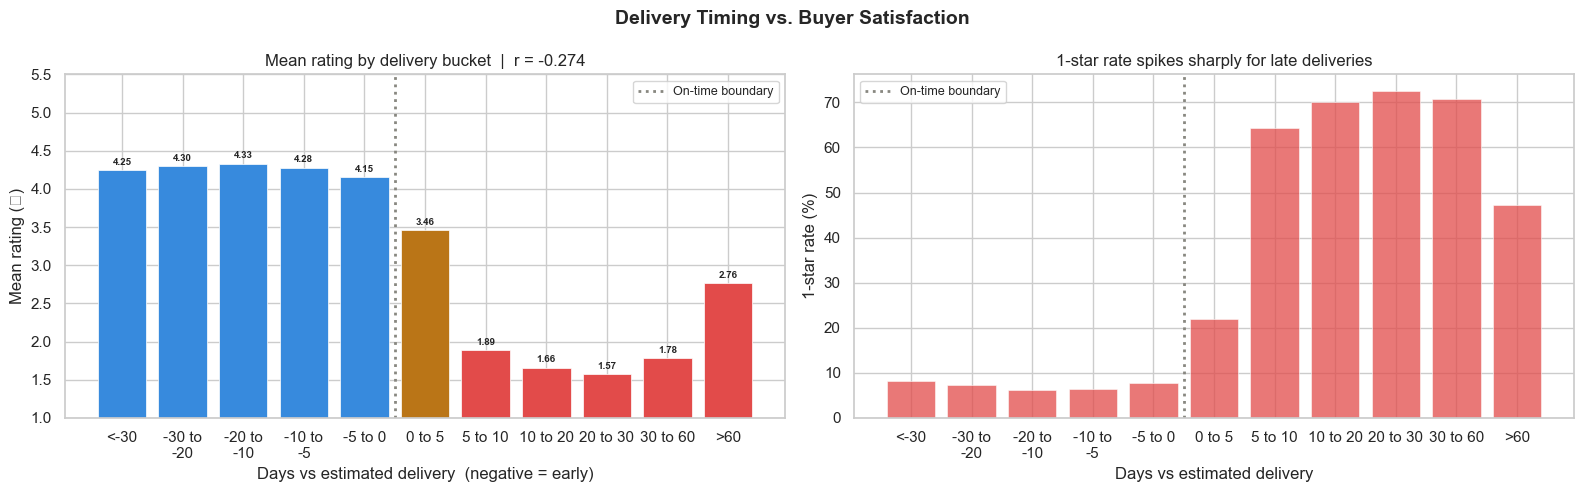

On-time/early — mean: 4.294, 1-star rate: 6.6%
Late           — mean: 2.564,  1-star rate: 46.3%


In [139]:
# Section 9 — Delivery timing vs. buyer satisfaction

delta_rating = (
    transactions[['transaction_id', 'delivery_delta']]
    .merge(feedback[['transaction_id', 'rating_score']], on='transaction_id', how='inner')
    .dropna()
)
delta_rating = delta_rating[
    (delta_rating['delivery_delta'] >= -60) &
    (delta_rating['delivery_delta'] <= 120)
]

pearson_r = delta_rating['delivery_delta'].corr(delta_rating['rating_score'])
print(f"Pearson r (delivery_delta vs rating_score): {pearson_r:.4f}  n={len(delta_rating):,}")

bucket_edges  = [-60, -30, -20, -10, -5, 0, 5, 10, 20, 30, 60, 120]
bucket_labels = ['<-30', '-30 to\n-20', '-20 to\n-10', '-10 to\n-5',
                 '-5 to 0', '0 to 5', '5 to 10', '10 to 20', '20 to 30', '30 to 60', '>60']
delta_rating['bucket'] = pd.cut(delta_rating['delivery_delta'],
                                bins=bucket_edges, labels=bucket_labels)

binned = delta_rating.groupby('bucket', observed=True).agg(
    mean_rating = ('rating_score', 'mean'),
    pct_1star   = ('rating_score', lambda x: (x == 1).mean() * 100),
    count       = ('rating_score', 'count'),
).reset_index()

bar_colors = [BLUE if r >= 4.0 else (AMBER if r >= 3.0 else RED)
              for r in binned['mean_rating']]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Delivery Timing vs. Buyer Satisfaction', fontsize=14, fontweight='bold')

ax = axes[0]
bars = ax.bar(binned['bucket'], binned['mean_rating'],
              color=bar_colors, edgecolor='white', linewidth=0.5)
ax.axvline(x=4.5, color=GRAY, linestyle=':', linewidth=2, label='On-time boundary')
ax.set_ylim(1, 5.5)
ax.set_xlabel('Days vs estimated delivery  (negative = early)')
ax.set_ylabel('Mean rating (★)')
ax.set_title(f'Mean rating by delivery bucket  |  r = {pearson_r:.3f}')
ax.legend(fontsize=9)
for bar, val, n in zip(bars, binned['mean_rating'], binned['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.07,
            f'{val:.2f}', ha='center', fontsize=7, fontweight='bold')

ax = axes[1]
ax.bar(binned['bucket'], binned['pct_1star'],
       color=RED, alpha=0.75, edgecolor='white', linewidth=0.5)
ax.axvline(x=4.5, color=GRAY, linestyle=':', linewidth=2, label='On-time boundary')
ax.set_xlabel('Days vs estimated delivery')
ax.set_ylabel('1-star rate (%)')
ax.set_title('1-star rate spikes sharply for late deliveries')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(figpath('fig4_delivery_vs_rating.png'), dpi=150, bbox_inches='tight')
plt.show()

late    = delta_rating[delta_rating['delivery_delta'] >  0]['rating_score']
on_time = delta_rating[delta_rating['delivery_delta'] <= 0]['rating_score']
print(f"On-time/early — mean: {on_time.mean():.3f}, 1-star rate: {(on_time==1).mean():.1%}")
print(f"Late           — mean: {late.mean():.3f},  1-star rate: {(late==1).mean():.1%}")


Late deliveries analysed: 7,825
  Ship threshold: 3 days from purchase

responsibility
Artisan (slow to ship)                   4436
Carrier (shipped on time, still late)    3389

  Artisan (slow to ship): 56.7%
  Carrier (shipped on time, still late): 43.3%

Mean rating and 1-star rate by responsibility:
                       responsibility  mean_rating  pct_1star    n
               Artisan (slow to ship)       2.5442    46.8261 4348
Carrier (shipped on time, still late)       2.5924    45.4408 3312


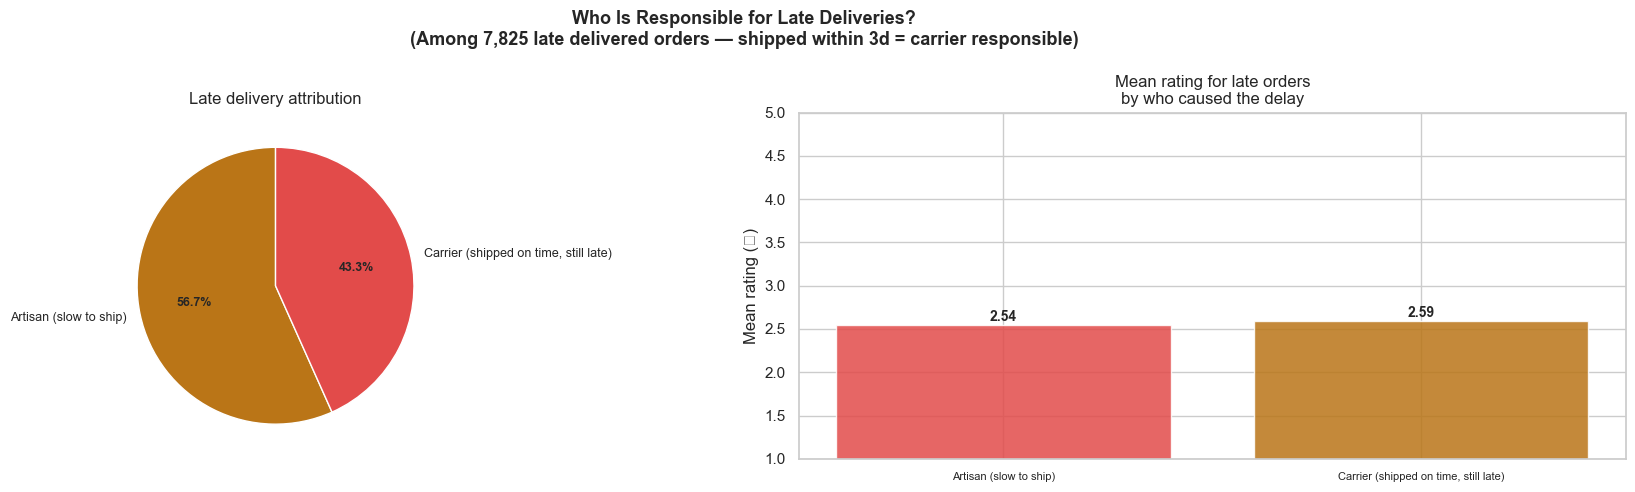

Saved: fig6_logistics_accountability.png

Key finding: 43% of late deliveries occurred despite the artisan shipping
  within 3 days. These artisans are absorbing a satisfaction penalty
  for carrier delays outside their control.
  57% of late deliveries are attributable to slow artisan dispatch.


In [140]:
# Section 10 — Logistics accountability: carrier vs. artisan attribution
# Delivery complaints dominate 1-star reviews, but 'delivery' is ambiguous:
#   - Artisan delay  : time from purchase to shipment (days_to_ship) — artisan controls this
#   - Carrier delay  : time from shipment to delivery  — logistics partner controls this
#
# We decompose late deliveries into artisan-caused vs carrier-caused to determine
# how much of the satisfaction penalty artisans are absorbing unfairly.
#
# Method: for late orders (delivery_delta > 0), compare days_to_ship vs a reasonable
# shipping threshold (3 days = typical artisan SLA). If the artisan shipped on time
# but the order still arrived late, the carrier is responsible.

SHIP_THRESHOLD = 3  # days — artisan is considered 'on time' if shipped within 3 days

late_tx = (
    transactions[
        (transactions['transaction_status'] == 'delivered') &
        (transactions['delivery_delta'] > 0) &
        transactions['days_to_ship'].notna() &
        transactions['delivery_delta'].notna()
    ].copy()
)

late_tx['artisan_shipped_late'] = late_tx['days_to_ship'] > SHIP_THRESHOLD

# Responsibility classification:
#   Artisan only   : artisan shipped late AND order arrived late
#   Carrier only   : artisan shipped on time BUT order still arrived late
#   Shared         : artisan shipped late (carrier may have compounded it)
late_tx['responsibility'] = late_tx['artisan_shipped_late'].map({
    True:  'Artisan (slow to ship)',
    False: 'Carrier (shipped on time, still late)',
})

resp_counts = late_tx['responsibility'].value_counts()
resp_pct    = resp_counts / len(late_tx) * 100

print(f"Late deliveries analysed: {len(late_tx):,}")
print(f"  Ship threshold: {SHIP_THRESHOLD} days from purchase\n")
print(resp_counts.to_string())
print()
for label, pct in resp_pct.items():
    print(f"  {label}: {pct:.1f}%")

# Does the satisfaction penalty differ by who caused the delay?
late_with_rating = late_tx.merge(
    feedback[['transaction_id','rating_score']], on='transaction_id', how='inner'
).dropna(subset=['rating_score'])

rating_by_resp = late_with_rating.groupby('responsibility')['rating_score'].agg(
    mean_rating='mean',
    pct_1star=lambda x: (x==1).mean()*100,
    n='count'
).reset_index()
print("\nMean rating and 1-star rate by responsibility:")
print(rating_by_resp.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Who Is Responsible for Late Deliveries?\n'
             f'(Among {len(late_tx):,} late delivered orders — shipped within {SHIP_THRESHOLD}d = carrier responsible)',
             fontsize=13, fontweight='bold')

# Panel A: responsibility pie
ax = axes[0]
resp_colors = [AMBER, RED]
wedges, texts, autotexts = ax.pie(
    resp_counts.values, labels=resp_counts.index,
    colors=resp_colors[:len(resp_counts)],
    autopct='%1.1f%%', startangle=90, textprops={'fontsize': 9},
)
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title('Late delivery attribution')

# Panel B: mean rating by responsibility
ax = axes[1]
bar_colors = [AMBER if 'Carrier' in r else RED for r in rating_by_resp['responsibility']]
bars = ax.bar(rating_by_resp['responsibility'], rating_by_resp['mean_rating'],
              color=bar_colors, alpha=0.85, edgecolor='white')
ax.set_ylim(1, 5)
ax.set_ylabel('Mean rating (★)')
ax.set_title('Mean rating for late orders\nby who caused the delay')
ax.tick_params(axis='x', labelsize=8)
for bar, v in zip(bars, rating_by_resp['mean_rating']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.05,
            f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(figpath('fig6_logistics_accountability.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig6_logistics_accountability.png')

# Summary interpretation
carrier_pct = resp_pct.get('Carrier (shipped on time, still late)', 0)
artisan_pct = resp_pct.get('Artisan (slow to ship)', 0)
print(f"\nKey finding: {carrier_pct:.0f}% of late deliveries occurred despite the artisan shipping")
print(f"  within {SHIP_THRESHOLD} days. These artisans are absorbing a satisfaction penalty")
print(f"  for carrier delays outside their control.")
print(f"  {artisan_pct:.0f}% of late deliveries are attributable to slow artisan dispatch.")


In [141]:
# Section 11 — Classifier: P(1-star rating) for any given artisan
#
# TARGET: pct_1star >= 0.15 (at least 15% of an artisan's reviews are 1-star)
#
# Feature selection rationale:
#   avg_delivery_delta  EXCLUDED — post-hoc (known only after delivery completes)
#   pct_late_deliveries EXCLUDED — data leakage (correlated with 1-star count)
#   avg_rating          EXCLUDED — encodes the target
#   n_1star             EXCLUDED — used to construct the target
#
# All remaining features are observable before or independent of any given review.

FEATURES = [
    'avg_item_price',      # price tier → buyer expectations
    'avg_photos',          # listing quality
    'avg_desc_length',     # listing completeness
    'avg_shipping_cost',   # cost burden to buyer
    'tenure_days',         # platform experience
    'unique_categories',   # catalog breadth
    'avg_installments',    # payment sensitivity proxy
]

# ── Build modelling dataframe ──────────────────────────────────────────────────
model_df = artisan_features[FEATURES + ['n_1star', 'num_ratings', 'artisan_id', 'quadrant']].dropna().copy()
model_df['pct_1star']       = model_df['n_1star'] / model_df['num_ratings']
model_df['high_1star_rate'] = (model_df['pct_1star'] >= 0.15).astype(int)

platform_1star_median = model_df['pct_1star'].median()
print(f'Platform median 1-star rate : {platform_1star_median:.1%}')
print(f'Threshold used              : 15%  (~2x platform median)')

vc = model_df['high_1star_rate'].value_counts()
print(f'\n=== Class distribution ===')
print(f'  Low 1-star rate  (<15%) : {vc[0]:,}  ({vc[0]/len(model_df):.1%})')
print(f'  High 1-star rate (>=15%): {vc[1]:,}  ({vc[1]/len(model_df):.1%})')
print(f'  Total artisans          : {len(model_df):,}')

# ── VIF check ─────────────────────────────────────────────────────────────────
X_vif = model_df[FEATURES].copy()
vif_df = pd.DataFrame({
    'feature': FEATURES,
    'VIF':     [variance_inflation_factor(X_vif.values, i) for i in range(len(FEATURES))]
}).sort_values('VIF', ascending=False)
print(f'\n=== VIF check ===')
print(vif_df.to_string(index=False))

high_vif = vif_df[vif_df['VIF'] > 10]['feature'].tolist()
if high_vif:
    print(f'\n  WARNING: VIF > 10 for {high_vif} — dropping')
    FEATURES = [f for f in FEATURES if f not in high_vif]
else:
    print(f'\n  No features with VIF > 10 — all {len(FEATURES)} retained')

# ── Train / val / test split ───────────────────────────────────────────────────
X = model_df[FEATURES]
y = model_df['high_1star_rate']

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f'\n=== Split sizes ===')
print(f'  Train+Val: {len(X_trainval):,}  |  Test: {len(X_test):,}')
print(f'  Train+Val high-1star rate: {y_trainval.mean():.1%}')
print(f'  Test high-1star rate     : {y_test.mean():.1%}')

# ── Stratified 5-fold CV ───────────────────────────────────────────────────────
skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_aucs = []

print(f'\n=== 5-fold CV ===')
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), 1):
    X_tr, X_v = X_trainval.iloc[tr_idx], X_trainval.iloc[val_idx]
    y_tr, y_v = y_trainval.iloc[tr_idx], y_trainval.iloc[val_idx]
    m = GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=42
    )
    m.fit(X_tr, y_tr)
    auc = roc_auc_score(y_v, m.predict_proba(X_v)[:, 1])
    cv_aucs.append(auc)
    print(f'  Fold {fold}: AUC = {auc:.4f}')

print(f'\n  CV mean AUC: {np.mean(cv_aucs):.4f} +/- {np.std(cv_aucs):.4f}')

# ── Final model on train+val, evaluate once on test ───────────────────────────
clf = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=42
)
clf.fit(X_trainval, y_trainval)
test_auc = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])

print(f'\n=== Final model ===')
print(f'  Held-out Test AUC: {test_auc:.4f}')
if abs(np.mean(cv_aucs) - test_auc) < 0.03:
    print('  CV ≈ Test → no overfitting')
else:
    print('  CV vs Test gap → possible overfitting — inspect')

print('\n  Classification report (threshold = 0.5):')
print(classification_report(
    y_test, clf.predict(X_test),
    target_names=['Low 1-star rate', 'High 1-star rate']
))

# ── Key finding: model is weak without delivery data ──────────────────────────
if test_auc < 0.65:
    print('  NOTE: AUC near 0.50-0.65 confirms that observable artisan')
    print('  characteristics (listing quality, price, tenure) have limited')
    print('  predictive power without delivery performance data.')
    print('  Delivery delta — excluded as post-hoc — is the dominant driver.')

# ── Score all artisans and attach to artisan_features ─────────────────────────
all_X = artisan_features[FEATURES].fillna(artisan_features[FEATURES].median())
artisan_features['p_high_1star'] = clf.predict_proba(all_X)[:, 1]

dz_mask = artisan_features['quadrant'] == 'Danger Zone'
print(f'\n=== Danger Zone predicted risk ===')
print(f'  DZ median p(high_1star_rate)   : {artisan_features.loc[dz_mask,  "p_high_1star"].median():.3f}')
print(f'  Rest median p(high_1star_rate) : {artisan_features.loc[~dz_mask, "p_high_1star"].median():.3f}')

# ── SHAP ──────────────────────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

mean_shap = np.abs(sv).mean(axis=0)
shap_df   = pd.DataFrame({
    'feature'   : FEATURES,
    'mean_shap' : mean_shap
}).sort_values('mean_shap', ascending=True)

LISTING_FEATS = {'avg_photos', 'avg_desc_length'}

def feat_color(f):
    if f in LISTING_FEATS: return GREEN
    return BLUE

shap_df['color'] = shap_df['feature'].apply(feat_color)

print(f'\n=== Top SHAP features ===')
print(shap_df[['feature','mean_shap']].sort_values('mean_shap', ascending=False).to_string(index=False))


Platform median 1-star rate : 10.0%
Threshold used              : 15%  (~2x platform median)

=== Class distribution ===
  Low 1-star rate  (<15%) : 1,309  (69.3%)
  High 1-star rate (>=15%): 581  (30.7%)
  Total artisans          : 1,890



=== VIF check ===
          feature    VIF
 avg_installments 6.2867
avg_shipping_cost 4.5655
       avg_photos 3.4629
      tenure_days 3.3473
  avg_desc_length 3.0618
   avg_item_price 2.4554
unique_categories 2.2627

  No features with VIF > 10 — all 7 retained

=== Split sizes ===
  Train+Val: 1,512  |  Test: 378
  Train+Val high-1star rate: 30.8%
  Test high-1star rate     : 30.7%

=== 5-fold CV ===
  Fold 1: AUC = 0.4976
  Fold 2: AUC = 0.4937
  Fold 3: AUC = 0.5167
  Fold 4: AUC = 0.5114
  Fold 5: AUC = 0.5849

  CV mean AUC: 0.5209 +/- 0.0331

=== Final model ===
  Held-out Test AUC: 0.5684
  CV vs Test gap → possible overfitting — inspect

  Classification report (threshold = 0.5):
                  precision    recall  f1-score   support

 Low 1-star rate       0.70      0.90      0.79       262
High 1-star rate       0.34      0.11      0.17       116

        accuracy                           0.66       378
       macro avg       0.52      0.51      0.48       378
    weig

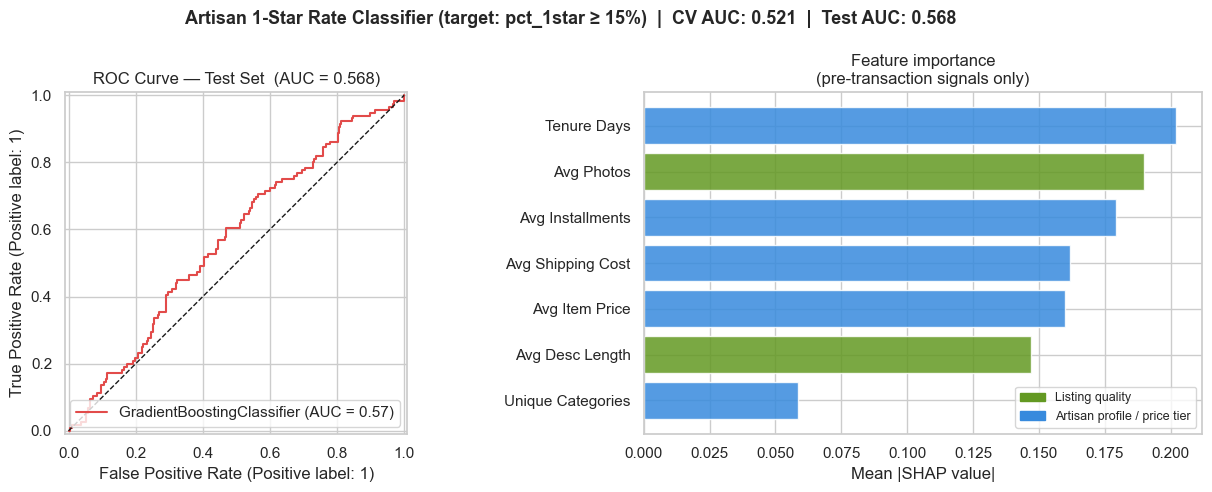

Saved: fig_classifier.png


In [142]:
# Section 11 (cont.) — Classifier visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    f'Artisan 1-Star Rate Classifier (target: pct_1star ≥ 15%)  |  '
    f'CV AUC: {np.mean(cv_aucs):.3f}  |  Test AUC: {test_auc:.3f}',
    fontsize=13, fontweight='bold'
)

# Panel 1 — ROC curve
RocCurveDisplay.from_estimator(clf, X_test, y_test, ax=axes[0], color=RED)
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_title(f'ROC Curve — Test Set  (AUC = {test_auc:.3f})')

# Panel 2 — SHAP bar chart
ax = axes[1]
ax.barh(
    shap_df['feature'].str.replace('_', ' ').str.title(),
    shap_df['mean_shap'],
    color=shap_df['color'], alpha=0.85, edgecolor='white'
)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Feature importance\n(pre-transaction signals only)')
legend_handles = [
    mpatches.Patch(color=GREEN, label='Listing quality'),
    mpatches.Patch(color=BLUE,  label='Artisan profile / price tier'),
]
ax.legend(handles=legend_handles, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig(figpath('fig_classifier.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_classifier.png')
